<a href="https://colab.research.google.com/github/Kashishkewat/python_practice/blob/main/day25_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ridge Regression**

**Ridge Regression is a regularized linear regression technique that adds a penalty to the loss function to reduce overfitting.**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

In [3]:
data=load_diabetes()

In [4]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [5]:
X=data.data
y=data.target
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [6]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [7]:
lr.fit(X_train,y_train)

LinearRegression()

In [8]:
y_pred=lr.predict(X_test)

In [9]:
from sklearn.metrics import r2_score,mean_squared_error
print(r2_score(y_test,y_pred))
print("ROOT MEAN SQUARE ERROR",np.sqrt(mean_squared_error(y_test,y_pred)))

0.5188113124539249
ROOT MEAN SQUARE ERROR 48.72713760953253


In [10]:
from sklearn.linear_model import Ridge
r=Ridge(alpha=0.0001,solver="cholesky")

In [11]:
r.fit(X_train,y_train)

Ridge(alpha=0.0001, solver='cholesky')

In [12]:
y_pred1=r.predict(X_test)

In [13]:
from sklearn.metrics import r2_score,mean_squared_error
print(r2_score(y_test,y_pred1))
print("ROOT MEAN SQUARE ERROR",np.sqrt(mean_squared_error(y_test,y_pred1)))

0.5189732635884949
ROOT MEAN SQUARE ERROR 48.71893700181956


# **Ridge Regression from scratch slope and intercept**

---



In [14]:
from sklearn.datasets import make_regression
X1,y1=make_regression(n_samples=100,n_features=1,n_informative=1,random_state=13,noise=20)

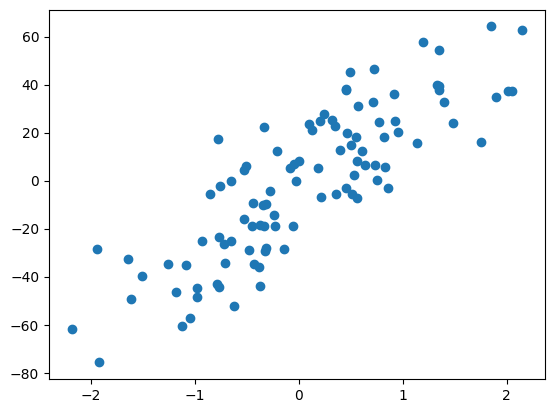

In [15]:
plt.scatter(X1,y1)

In [16]:
from sklearn.linear_model import  LinearRegression
lr1=LinearRegression()

In [17]:
lr1.fit(X1,y1)

LinearRegression()

In [18]:
print(lr1.coef_)
print(lr1.intercept_)

[27.82809103]
-2.29474455867698


In [19]:
from sklearn.linear_model import Ridge

In [20]:
rr=Ridge(alpha=10)
rr.fit(X1,y1)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235735


In [21]:
rr1=Ridge(alpha=100)
rr1.fit(X1,y1)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


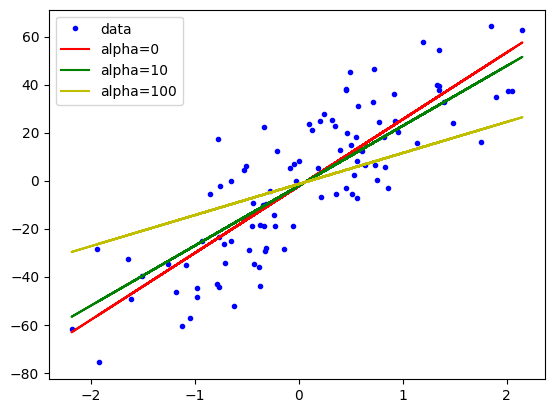

In [22]:
plt.plot(X1,y1,"b.",label="data")
plt.plot(X1,lr1.predict(X1),"r-",label="alpha=0")
plt.plot(X1,rr.predict(X1),"g-",label='alpha=10')
plt.plot(X1,rr1.predict(X1),"y-",label='alpha=100')
plt.legend()

In [42]:
class meraridge:
  def __init__(self,alpha=0.1):
    self.alpha=alpha
    self.m=None
    self.b=None
  def fit(self,X_train,y_train):
   num=0
   den=0
   for i in range(X_train.shape[0]):
    num=num +(y_train[i]-y_train.mean())*(X_train[i]-X_train.mean())
    den=den+(X_train[i]-X_train.mean())**2
   self.m=num/(den+self.alpha)
   self.b=y_train.mean()-(self.m*X_train.mean())
   print(self.m,self.b)

  def predict(self,X_test):
    return self.m * X_test + self.b

In [43]:
mr=meraridge(alpha=10)
mr.fit(X1,y1)

[24.9546267] [-2.126913]


In [45]:
y_pred9=mr.predict(X1)

In [48]:
print(mr.m)
print(mr.b)

[24.9546267]
[-2.126913]


In [29]:
class MeraRidge:
  def __init__(self,alpha=0.1):
    self.alpha=alpha
    self.m=None
    self.b=None
  def fit(self,X_train,y_train):
    X_train=np.insert(X_train,0,1,axis=1)
    I=np.identity(X_train.shape[1])
    result=np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha *I).dot(X_train.T).dot(y_train)
    self.m=result[1:]
    self.b=result[0]
  def predict(self,X_test):
    return np.dot(X_test,self.m)+self.b

In [37]:
MR=MeraRidge()
MR.fit(X_train,y_train)

In [38]:
y_pred=MR.predict(X_test)

In [39]:
print(r2_score(y_test,y_pred))
print(MR.m)
print(MR.b)

0.5208372379246831
[  31.06666115 -204.84307035  464.93516756  304.93249375  -95.7514605
  -87.53345176 -183.80619875  147.45795459  425.84778419  110.23078509]
152.02810181403376
